In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [74]:
df = pd.read_csv('../scraper/movies.csv')
df.head()

,id,title,release_date,popularity,vote_average,vote_count,genre_ids,original_language
0,1226863,The Super Mario Galaxy Movie,2026-04-01,718.7308,6.815,492,10751|35|12|14|16,en
1,1523145,Your Heart Will Be Broken,2026-03-26,377.5413,7.200,61,10749|18,ru
2,83533,Avatar: Fire and Ash,2025-12-17,306.1776,7.369,2626,878|12|14,en
3,687163,Project Hail Mary,2026-03-15,263.6881,8.214,1503,878|12,en
4,980431,"Avatar: Aang, The Last Airbender",2026-10-09,235.9757,0.000,0,16|28|12|14,en


Remove films without key values

In [75]:
df = df.dropna(subset=['vote_average', 'vote_count', 'release_date'])

Filter out films with invalid values


In [76]:
df = df[df['vote_count'] >= 5]
df = df[df['vote_average'].between(1, 10)]
df = df[df['popularity'] > 0]

Analyze missing values(EDA)

id                   0
title                0
release_date         0
popularity           0
vote_average         0
vote_count           0
genre_ids            0
original_language    0
dtype: int64


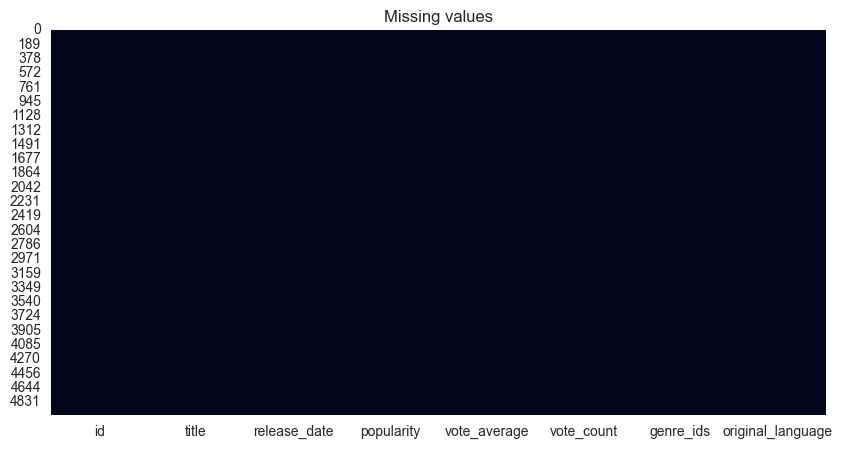

In [77]:
print(df.isnull().sum())

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing values")
plt.show()

Převod textového data na datetime formát
Vytvoření nových časových features
Formating text date into datetime values
if date is wrong format instead is gonna be save as Nan
removing rows with Nan date


In [78]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df = df.dropna(subset=['release_date'])

df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

Calculate the age of film if release date is in future the values is set 0

In [79]:
CURRENT_YEAR = datetime.now().year

df['film_age'] = CURRENT_YEAR - df['release_year']
df['film_age'] = df['film_age'].clip(lower=0)

removing outliners in 99% quantile

In [80]:
df = df[df['vote_count'] < df['vote_count'].quantile(0.99)]
df = df[df['popularity'] < df['popularity'].quantile(0.99)]

# Feature engineering

creating new values for model to understand it better
IT uses log to convert larger numbers into smaller numbers


engagement ratio is How much vote does it have against the popularity

votes per year How much votes does it have while existing in market

In [81]:
df['log_vote_count'] = np.log1p(df['vote_count'])
df['log_popularity'] = np.log1p(df['popularity'])

df['engagement_ratio'] = df['vote_count'] / (df['popularity'] + 1)
df['log_engagement'] = np.log1p(df['engagement_ratio'])

df['votes_per_year'] = df['vote_count'] / (df['film_age'] + 1)
df['popularity_per_year'] = df['popularity'] / (df['film_age'] + 1)

LANGUAGE RARITY

Value that's calculate how films are in the same language
model can find diffrent patterns for in diffrents languages

In [82]:

lang_freq = df['original_language'].value_counts(normalize=True)
df['language_rarity'] = df['original_language'].map(lang_freq)

ENCODING JAZYKA

Dataset top 10 most based languages and others gonna be put in category other
One hot encoding is gonna make colummns for each languages in top 10 for model to understand it better

In [83]:

top_languages = df['original_language'].value_counts().nlargest(10).index


df['original_language'] = df['original_language'].apply(
    lambda x: x if x in top_languages else 'other'
)

# One-hot encoding jazyka
df = pd.get_dummies(df, columns=['original_language'])

Converting string of genres into list of numbers

takes all unique genres and create a column for them


Calculates number of genre in film and save the number in seperate column after that it deletes the  genre_ids column

In [84]:
df['genre_ids'] = df['genre_ids'].apply(
    lambda x: list(map(int, x.split('|'))) if isinstance(x, str) else []
)

all_genres = set()
for g in df['genre_ids']:
    all_genres.update(g)

for genre in all_genres:
    df[f'genre_{genre}'] = df['genre_ids'].apply(
        lambda x: int(genre in x)
    )

df['genre_count'] = df['genre_ids'].apply(len)
df = df.drop(columns=['genre_ids'])

TREND SCORE

Trend score measures the popularity of a movie relative to its age, highlighting whether the movie is currently trending or just historically popular.

In [85]:
df['trend_score'] = df['popularity'] / (df['film_age'] + 1)

popularity_score

Popularity_score combines popularity and vote count to see how the film is realy popular


In [86]:
df['popularity_score'] = df['popularity'] * df['vote_count']

SAFETY FEATURE CLEANING

In [87]:
# odstranění nekonečných a NaN hodnot
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()
df = df.drop_duplicates()

Visualization betwenn popularity and rating


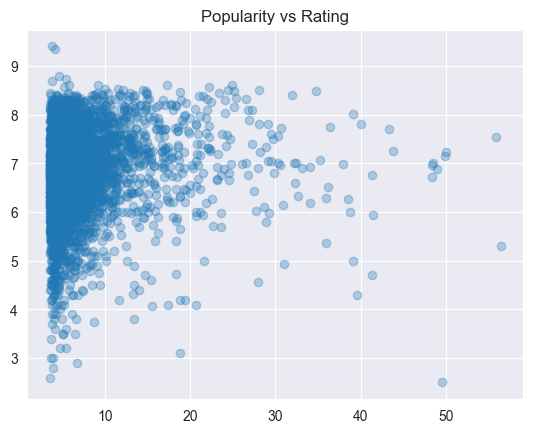

In [88]:
plt.scatter(df['popularity'], df['vote_average'], alpha=0.3)
plt.title("Popularity vs Rating")
plt.show()

Heat map

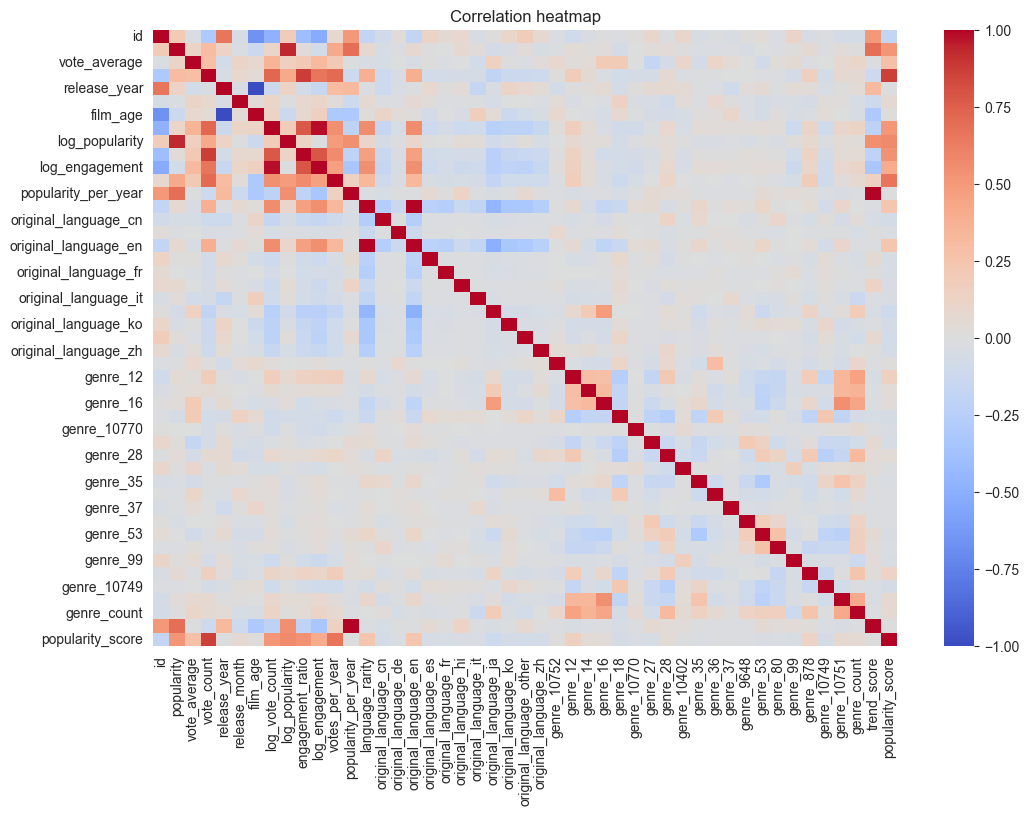

vote_average        1.000000
log_vote_count      0.351677
log_engagement      0.315590
vote_count          0.288549
popularity_score    0.279242
engagement_ratio    0.218669
votes_per_year      0.212696
genre_16            0.202655
genre_18            0.198162
log_popularity      0.159485
Name: vote_average, dtype: float64

In [89]:
# Korelační matice
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation heatmap")
plt.show()

df.corr(numeric_only=True)['vote_average'] \
  .sort_values(ascending=False) \
  .head(10)

Final Control

In [90]:
print("Final shape:", df.shape)
print(df.columns)

Final shape: (4581, 49)
Index(['id', 'title', 'release_date', 'popularity', 'vote_average',
       'vote_count', 'release_year', 'release_month', 'film_age',
       'log_vote_count', 'log_popularity', 'engagement_ratio',
       'log_engagement', 'votes_per_year', 'popularity_per_year',
       'language_rarity', 'original_language_cn', 'original_language_de',
       'original_language_en', 'original_language_es', 'original_language_fr',
       'original_language_hi', 'original_language_it', 'original_language_ja',
       'original_language_ko', 'original_language_other',
       'original_language_zh', 'genre_10752', 'genre_12', 'genre_14',
       'genre_16', 'genre_18', 'genre_10770', 'genre_27', 'genre_28',
       'genre_10402', 'genre_35', 'genre_36', 'genre_37', 'genre_9648',
       'genre_53', 'genre_80', 'genre_99', 'genre_878', 'genre_10749',
       'genre_10751', 'genre_count', 'trend_score', 'popularity_score'],
      dtype='str')


EXPORT DATA

In [91]:
df.to_csv("movies_clean.csv", index=False)
print("Saved: movies_clean.csv")

Saved: movies_clean.csv
